In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"

import torch
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of visible GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

1
NVIDIA L40S
CUDA available: True
Number of visible GPUs: 1
Device 0: NVIDIA L40S


In [6]:
# ============================================================================
# IMPORTS
# ============================================================================

import cv2
import numpy as np
import random
import torch
import gc
import os
import pandas as pd
import hashlib
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import json
import time
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, classification_report
)

import matplotlib.pyplot as plt

/mnt/NAS3/homes/rmuthy2/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# ============================================================================
# CONFIGURATION
# ============================================================================

ROOT_PATH  = "/home/rmuthy2/central_data/datasets/internal/EmoryCXRv2/ORIGINAL_PNG"
TRAIN_CSV  = "/home/rmuthy2/Machine-Induced Noise/train.csv"
TEST_CSV   = "/home/rmuthy2/Machine-Induced Noise/test.csv"
OUTPUT_DIR = "/home/rmuthy2/Machine-Induced Noise/Localized_Blur_8*8"

# --- Localised blur parameters ---
# Two scales: 16 px (micro-calcification) and 64 px (hairline fracture / small lesion)
PATCH_SIZES    = [8]
NUM_PATCHES    = 1          # patches injected per image
BLUR_KSIZE     = 21         # Gaussian kernel; must be odd; larger = stronger local blur
BLUR_SIGMA     = 0          # 0 → OpenCV auto-selects based on ksize

# Anatomical placement: patches go in the central 60% of the image
# (avoids black padding borders and stays in lung/rib territory)
PLACEMENT_MARGIN = 0.20     # 20% margin from each edge

BATCH_SIZE = 12

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [8]:
# ============================================================================
# CLASSES
# ============================================================================

class ImagePreprocessor:
    """Unchanged from Motion_Blur pipeline — pads to square and resizes to 1024×1024."""

    def __init__(self, target_size=(1024, 1024)):
        self.target_size = target_size

    def analyze_image_color_distribution(self, image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image

        hist = cv2.calcHist([gray], [0], None, [256], [0, 256]).flatten()
        hist_for_peaks = hist.copy()
        hist_for_peaks[:21]  = 0
        hist_for_peaks[235:] = 0

        mode_value = np.argmax(hist_for_peaks) if np.sum(hist_for_peaks) > 0 else 128
        if mode_value <= 20 or mode_value >= 235:
            mode_value = 128

        min_noise_color = max(20,  mode_value - 20)
        max_noise_color = min(235, mode_value + 20)

        return mode_value, (min_noise_color, max_noise_color), hist

    def pad_to_square_and_resize(self, image_path):
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Cannot load: {image_path}")

        mode_value, noise_range, hist = self.analyze_image_color_distribution(image)
        color_analysis = {'mode_value': mode_value, 'noise_range': noise_range, 'histogram': hist}

        h, w     = image.shape[:2]
        max_dim  = max(h, w, 3052)
        pad_h, pad_w = max_dim - h, max_dim - w
        top, bottom  = pad_h // 2, pad_h - pad_h // 2
        left, right  = pad_w // 2, pad_w - pad_w // 2

        if len(image.shape) == 3:
            padded = cv2.copyMakeBorder(image, top, bottom, left, right,
                                        cv2.BORDER_CONSTANT, value=[0, 0, 0])
        else:
            padded = cv2.copyMakeBorder(image, top, bottom, left, right,
                                        cv2.BORDER_CONSTANT, value=0)

        resized = cv2.resize(padded, self.target_size, interpolation=cv2.INTER_LANCZOS4)
        return resized, color_analysis


class LocalizedBlurInjector:
    """
    Injects clinically-motivated localised Gaussian blur patches.

    Clinical rationale
    ------------------
    • 16×16 px patches  → micro-calcification clusters: small foci of calcium
      density that appear as tiny bright spots on CXR.  Blurring at this scale
      destroys the sharp density boundary that distinguishes calcification from
      surrounding soft tissue — exactly the kind of fine-grained detail that
      global embeddings are hypothesised NOT to encode.

    • 64×64 px patches  → hairline fractures or early nodules: subtle linear
      opacities (rib cortex discontinuity) or small pulmonary nodules.  Blurring
      at this scale removes the sharp cortical edge or nodule margin while
      leaving large-scale lung anatomy intact.

    Patch placement is anatomically constrained to the central 60% of the image
    (avoiding black padding borders) and is deterministic per image via SHA-256
    seeding so the experiment is fully reproducible.
    """

    def __init__(self, seed=42):
        self.seed = seed

    def _get_deterministic_seed(self, image_path):
        filename    = os.path.basename(image_path)
        seed_string = f"{self.seed}_{filename}"
        hash_object = hashlib.sha256(seed_string.encode())
        return int(hash_object.hexdigest()[:8], 16)

    def _sample_patch_origin(self, rng, image_h, image_w, patch_size, margin=PLACEMENT_MARGIN):
        """
        Sample a top-left (y, x) coordinate such that the patch:
        - stays fully within the image
        - is placed in the anatomical zone (central 1-2*margin fraction)
        """
        y_min = int(image_h * margin)
        y_max = int(image_h * (1 - margin)) - patch_size
        x_min = int(image_w * margin)
        x_max = int(image_w * (1 - margin)) - patch_size

        # Clamp so max >= min (safety for very small images)
        y_max = max(y_min + 1, y_max)
        x_max = max(x_min + 1, x_max)

        y = rng.integers(y_min, y_max)
        x = rng.integers(x_min, x_max)
        return int(y), int(x)

    def add_localized_blur(
        self,
        image,
        patch_sizes=PATCH_SIZES,
        num_patches=NUM_PATCHES,
        blur_ksize=BLUR_KSIZE,
        blur_sigma=BLUR_SIGMA,
        image_path=None
    ):
        """
        Apply localised Gaussian blur to `num_patches` small regions.

        Each patch independently picks one of the patch_sizes, so a single
        image may have a mix of 16px and 64px blurred regions — mimicking
        a radiograph with both micro-calcifications and a hairline fracture.

        Parameters
        ----------
        image        : np.ndarray  H×W or H×W×C  uint8
        patch_sizes  : list[int]   candidate patch edge lengths in pixels
        num_patches  : int         number of patches to inject
        blur_ksize   : int         Gaussian kernel size (must be odd)
        blur_sigma   : float       Gaussian sigma (0 = auto)
        image_path   : str|None    used to derive deterministic RNG seed

        Returns
        -------
        noisy : np.ndarray  same shape/dtype as image
        meta  : dict        patch_sizes_used, patch_locations
        """
        seed = self._get_deterministic_seed(image_path) if image_path else self.seed
        rng  = np.random.default_rng(seed)

        noisy  = image.copy()
        h, w   = image.shape[:2]

        # Pre-compute the globally blurred version once — extract patches from it
        # This is much faster than blurring the full image per patch
        blurred_full = cv2.GaussianBlur(image, (blur_ksize, blur_ksize), blur_sigma)

        patch_log = []  # [(y, x, size)] for reproducibility logging

        for _ in range(num_patches):
            ps  = int(rng.choice(patch_sizes))         # pick 16 or 64
            y, x = self._sample_patch_origin(rng, h, w, ps)

            # Replace the patch in noisy with the blurred version
            noisy[y:y+ps, x:x+ps] = blurred_full[y:y+ps, x:x+ps]
            patch_log.append({'y': y, 'x': x, 'size': ps})

        noisy = np.clip(noisy, 20, 235).astype(np.uint8)

        meta = {
            'patch_sizes_used': [p['size'] for p in patch_log],
            'patch_locations':   patch_log
        }
        return noisy, meta


class EmbeddingExtractor:
    """Unchanged from Motion_Blur pipeline."""

    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        self.load_raddino_model()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        self.load_dinov3_model()

    def load_raddino_model(self):
        try:
            print("Loading RAD-DINO model...")
            self.raddino_processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
            self.raddino_model     = AutoModel.from_pretrained("microsoft/rad-dino").to(self.device)
            self.raddino_model.eval()
            print("RAD-DINO model loaded successfully")
        except Exception as e:
            print(f"Error loading RAD-DINO model: {e}")
            self.raddino_model     = None
            self.raddino_processor = None

    def load_dinov3_model(self):
        try:
            print("Loading DINOv3 model...")
            self.dinov3_processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m")
            self.dinov3_model     = AutoModel.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m").to(self.device)
            self.dinov3_model.eval()
            print("DINOv3 model loaded successfully")
        except Exception as e:
            print(f"Error loading DINOv3 model: {e}")
            self.dinov3_model     = None
            self.dinov3_processor = None

    def _to_pil(self, image):
        if image.ndim == 3:
            return Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        else:
            return Image.fromarray(image).convert("RGB")

    def extract_batch(self, images):
        pil_list = [self._to_pil(im) for im in images]

        with torch.no_grad():
            # RAD-DINO
            if self.raddino_model is not None:
                inputs = self.raddino_processor(pil_list, return_tensors="pt").to(self.device)
                outputs = self.raddino_model(**inputs)
                if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                    raddino_embs = outputs.pooler_output
                else:
                    raddino_embs = outputs.last_hidden_state.mean(dim=1)
                raddino_embs = raddino_embs.detach().cpu().numpy()
            else:
                raddino_embs = None

            # DINOv3
            if self.dinov3_model is not None:
                inputs = self.dinov3_processor(pil_list, return_tensors="pt").to(self.device)
                outputs = self.dinov3_model(**inputs)
                if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                    dinov3_embs = outputs.pooler_output
                else:
                    dinov3_embs = outputs.last_hidden_state.mean(dim=1)
                dinov3_embs = dinov3_embs.detach().cpu().numpy()
            else:
                dinov3_embs = None

        return raddino_embs, dinov3_embs


class LinearProbingAnalyzer:
    """Unchanged from Motion_Blur pipeline — bootstrap CI logistic regression."""

    def __init__(self, n_bootstrap=1000, confidence_level=0.95):
        self.results          = {}
        self.n_bootstrap      = n_bootstrap
        self.confidence_level = confidence_level

    def load_embeddings(self, parquet_path, embedding_col):
        df = pd.read_parquet(parquet_path)
        valid_mask = df[embedding_col].notna()
        df_valid   = df[valid_mask].copy()

        embeddings, labels = [], []
        for _, row in df_valid.iterrows():
            emb = row[embedding_col]
            if isinstance(emb, str):
                import ast
                emb = ast.literal_eval(emb)
            if isinstance(emb, list):
                emb = np.array(emb)
            embeddings.append(emb)
            labels.append(row['noise'])

        X = np.vstack(embeddings)
        y = np.array(labels).astype(int)
        return X, y

    def _best_f1_threshold(self, y_true, y_proba):
        precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
        f1s = (2 * precisions[1:] * recalls[1:]) / (precisions[1:] + recalls[1:] + 1e-12)
        if len(f1s) == 0:
            return 0.5, 0.0
        idx = np.argmax(f1s)
        return float(thresholds[idx]), float(f1s[idx])

    def _bootstrap_metrics(self, y_test, y_test_proba, threshold):
        n_samples  = len(y_test)
        auc_scores = []
        f1_scores  = []

        for _ in range(self.n_bootstrap):
            indices       = np.random.choice(n_samples, size=n_samples, replace=True)
            y_boot        = y_test[indices]
            y_proba_boot  = y_test_proba[indices]

            if len(np.unique(y_boot)) > 1:
                auc_scores.append(roc_auc_score(y_boot, y_proba_boot))

            y_pred_boot = (y_proba_boot >= threshold).astype(int)
            f1_scores.append(f1_score(y_boot, y_pred_boot, zero_division=0))

        alpha  = 1 - self.confidence_level
        auc_ci = np.percentile(auc_scores, [100*alpha/2, 100*(1-alpha/2)]) if auc_scores else [0, 0]
        f1_ci  = np.percentile(f1_scores,  [100*alpha/2, 100*(1-alpha/2)])
        return auc_ci, f1_ci

    def train_and_evaluate(self, model_name, X_train, y_train, X_test, y_test):
        print(f"\nTraining {model_name.upper()}...")

        scaler        = StandardScaler()
        X_train_sc    = scaler.fit_transform(X_train)
        X_test_sc     = scaler.transform(X_test)

        model = LogisticRegression(random_state=42, max_iter=1000)
        model.fit(X_train_sc, y_train)

        y_test_proba = model.predict_proba(X_test_sc)[:, 1]
        auc_score    = roc_auc_score(y_test, y_test_proba)
        fpr, tpr, _  = roc_curve(y_test, y_test_proba)

        best_thr, _  = self._best_f1_threshold(y_test, y_test_proba)
        y_pred       = (y_test_proba >= best_thr).astype(int)
        f1           = f1_score(y_test, y_pred)

        print(f"Computing {self.confidence_level*100:.0f}% CI ({self.n_bootstrap} bootstrap samples)...")
        auc_ci, f1_ci = self._bootstrap_metrics(y_test, y_test_proba, best_thr)

        print(f"{model_name.upper()} - AUC: {auc_score:.4f} [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}] "
              f"| F1@{best_thr:.3f}: {f1:.4f} [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")
        print(classification_report(y_test, y_pred, digits=4))

        self.results[model_name] = {
            'auc': auc_score, 'auc_ci': auc_ci,
            'f1':  f1,        'f1_ci':  f1_ci,
            'threshold': best_thr,
            'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred
        }
        return auc_score, f1

    def plot_roc_curves(self, save_path):
        plt.figure(figsize=(10, 8))
        colors = {'raddino': '#2E86C1', 'dinov3': '#E74C3C'}

        for model_name in ['raddino', 'dinov3']:
            if model_name in self.results:
                r = self.results[model_name]
                auc_ci_str = f"[{r['auc_ci'][0]:.3f}–{r['auc_ci'][1]:.3f}]"
                f1_ci_str  = f"[{r['f1_ci'][0]:.3f}–{r['f1_ci'][1]:.3f}]"
                label = (f'{model_name.upper()} '
                         f'(AUC={r["auc"]:.3f} {auc_ci_str}, '
                         f'F1={r["f1"]:.3f} {f1_ci_str})')
                plt.plot(r['fpr'], r['tpr'],
                         color=colors[model_name], linewidth=2.5, label=label)

        plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title(
            f'Localised Blur Detection — ROC Curves\n'
            f'({NUM_PATCHES} patches × {{16,64}} px | Gaussian k={BLUR_KSIZE})',
            fontsize=14, fontweight='bold'
        )
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Plot saved: {save_path}")


class ProgressTracker:
    """Track completed tasks and enable checkpoint resumption."""

    def __init__(self, output_dir):
        self.output_dir    = output_dir
        self.progress_file = os.path.join(output_dir, "progress.json")
        self.load_progress()

    def load_progress(self):
        if os.path.exists(self.progress_file):
            with open(self.progress_file, 'r') as f:
                self.progress = json.load(f)
        else:
            self.progress = {
                "completed_tasks": [],
                "current_task":    None,
                "last_updated":    None
            }

    def save_progress(self):
        self.progress["last_updated"] = datetime.now().isoformat()
        os.makedirs(self.output_dir, exist_ok=True)
        with open(self.progress_file, 'w') as f:
            json.dump(self.progress, f, indent=2)

    def is_task_completed(self, task_id):
        return task_id in self.progress["completed_tasks"]

    def mark_task_completed(self, task_id):
        if task_id not in self.progress["completed_tasks"]:
            self.progress["completed_tasks"].append(task_id)
        self.save_progress()

    def set_current_task(self, task_id):
        self.progress["current_task"] = task_id
        self.save_progress()

In [9]:
# ============================================================================
# PIPELINE FUNCTIONS
# ============================================================================

def process_dataset(csv_path, split_name, preprocessor, injector, extractor,
                    batch_size=BATCH_SIZE, save_intermediate=True,
                    intermediate_save_frequency=50):
    """Process one split (train/test) with batched embedding extraction."""
    print(f"\n{'='*70}")
    print(f"PROCESSING {split_name.upper()} SET")
    print(f"{'='*70}")

    df = pd.read_csv(csv_path)
    df['full_path'] = df['ImagePath'].apply(lambda x: os.path.join(ROOT_PATH, x))

    results     = []
    num_batches = (len(df) + batch_size - 1) // batch_size

    if save_intermediate:
        intermediate_dir  = os.path.join(OUTPUT_DIR, "intermediate_saves")
        os.makedirs(intermediate_dir, exist_ok=True)
        intermediate_path = os.path.join(
            intermediate_dir, f"localized_blur_{split_name}_intermediate.parquet"
        )

    batch_count = 0
    for batch_idx in tqdm(range(num_batches), desc=f"Processing {split_name}"):
        batch_start_time = time.time()
        start_idx  = batch_idx * batch_size
        end_idx    = min(start_idx + batch_size, len(df))
        batch_df   = df.iloc[start_idx:end_idx]

        clean_images = []
        noisy_images = []
        patch_metas  = []
        valid_rows   = []

        for _, row in batch_df.iterrows():
            img_path = row['full_path']
            if not os.path.exists(img_path):
                continue
            try:
                processed, color_analysis = preprocessor.pad_to_square_and_resize(img_path)
                clean_images.append(processed)

                # --- KEY CHANGE: localised blur instead of global motion blur ---
                noisy, meta = injector.add_localized_blur(
                    processed,
                    patch_sizes=PATCH_SIZES,
                    num_patches=NUM_PATCHES,
                    blur_ksize=BLUR_KSIZE,
                    blur_sigma=BLUR_SIGMA,
                    image_path=img_path
                )
                noisy_images.append(noisy)
                patch_metas.append(meta)
                valid_rows.append(row)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue

        if len(clean_images) == 0:
            continue

        # Extract embeddings
        clean_rad, clean_dino = extractor.extract_batch(clean_images)
        noisy_rad, noisy_dino = extractor.extract_batch(noisy_images)

        # Store results
        for i, row in enumerate(valid_rows):
            base_record = {
                'AccessionNumber_anon': row.get('AccessionNumber_anon', ''),
                'ImagePath':            row['ImagePath'],
                'Cardiomegaly':         row.get('Cardiomegaly', 0),
            }

            # Clean image record (noise=0)
            results.append({
                **base_record,
                'noise':             0,
                'patch_meta':        None,
                'raddino_embedding': clean_rad[i].tolist()  if clean_rad  is not None else None,
                'dinov3_embedding':  clean_dino[i].tolist() if clean_dino is not None else None,
            })

            # Noisy image record (noise=1) — includes patch metadata for analysis
            results.append({
                **base_record,
                'noise':             1,
                'patch_meta':        json.dumps(patch_metas[i]),  # serialise dict → str
                'raddino_embedding': noisy_rad[i].tolist()  if noisy_rad  is not None else None,
                'dinov3_embedding':  noisy_dino[i].tolist() if noisy_dino is not None else None,
            })

        # Memory cleanup
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        batch_count += 1
        batch_time   = time.time() - batch_start_time

        if save_intermediate and (
            batch_count % intermediate_save_frequency == 0 or batch_count == num_batches
        ):
            pd.DataFrame(results).to_parquet(intermediate_path, index=False)

        if batch_count % 10 == 0 or batch_count == num_batches:
            print(f"\nBatch {batch_count}/{num_batches}: "
                  f"Time={batch_time:.2f}s, "
                  f"Images/sec={len(clean_images)/batch_time:.2f}")
            if batch_count < num_batches:
                remaining_batches = num_batches - batch_count
                estimated_time    = remaining_batches * batch_time / 60
                print(f"Estimated remaining time: {estimated_time:.1f} minutes")

    # Save final parquet
    results_df  = pd.DataFrame(results)
    output_path = os.path.join(OUTPUT_DIR, f"localized_blur_{split_name}.parquet")
    results_df.to_parquet(output_path, index=False)
    print(f"\nSaved: {output_path}")
    print(f"Total samples: {len(results_df)} ({results_df['noise'].value_counts().to_dict()})")
    return output_path


def run_linear_probing(train_path, test_path, n_bootstrap=1000, confidence_level=0.95):
    print(f"\n{'='*70}")
    print("LINEAR PROBING ANALYSIS WITH CONFIDENCE INTERVALS")
    print(f"{'='*70}")
    print(f"Bootstrap samples: {n_bootstrap}, Confidence level: {confidence_level*100:.0f}%")

    analyzer = LinearProbingAnalyzer(n_bootstrap=n_bootstrap, confidence_level=confidence_level)

    print("\nLoading embeddings...")
    X_train_rad,  y_train_rad  = analyzer.load_embeddings(train_path, 'raddino_embedding')
    X_test_rad,   y_test_rad   = analyzer.load_embeddings(test_path,  'raddino_embedding')
    X_train_dino, y_train_dino = analyzer.load_embeddings(train_path, 'dinov3_embedding')
    X_test_dino,  y_test_dino  = analyzer.load_embeddings(test_path,  'dinov3_embedding')

    print(f"Train samples: {len(X_train_rad)}, Test samples: {len(X_test_rad)}")

    analyzer.train_and_evaluate('raddino', X_train_rad,  y_train_rad,  X_test_rad,  y_test_rad)
    analyzer.train_and_evaluate('dinov3',  X_train_dino, y_train_dino, X_test_dino, y_test_dino)

    roc_path = os.path.join(OUTPUT_DIR, 'localized_blur_roc_curves.png')
    analyzer.plot_roc_curves(roc_path)

    print(f"\n{'='*70}")
    print("RESULTS SUMMARY")
    print(f"{'='*70}")
    print(f"{'Model':<10s} | {'AUC':<32s} | {'F1':<32s} | Threshold")
    print(f"{'-'*80}")
    for model, metrics in analyzer.results.items():
        auc_str = f"{metrics['auc']:.4f} [{metrics['auc_ci'][0]:.4f}–{metrics['auc_ci'][1]:.4f}]"
        f1_str  = f"{metrics['f1']:.4f}  [{metrics['f1_ci'][0]:.4f}–{metrics['f1_ci'][1]:.4f}]"
        print(f"{model.upper():<10s} | {auc_str:<32s} | {f1_str:<32s} | {metrics['threshold']:.3f}")
    print(f"{'='*70}")

    return analyzer

Saved visualisation: /home/rmuthy2/Machine-Induced Noise/Localized_Blur_8*8/sample_patch_visualisation.png


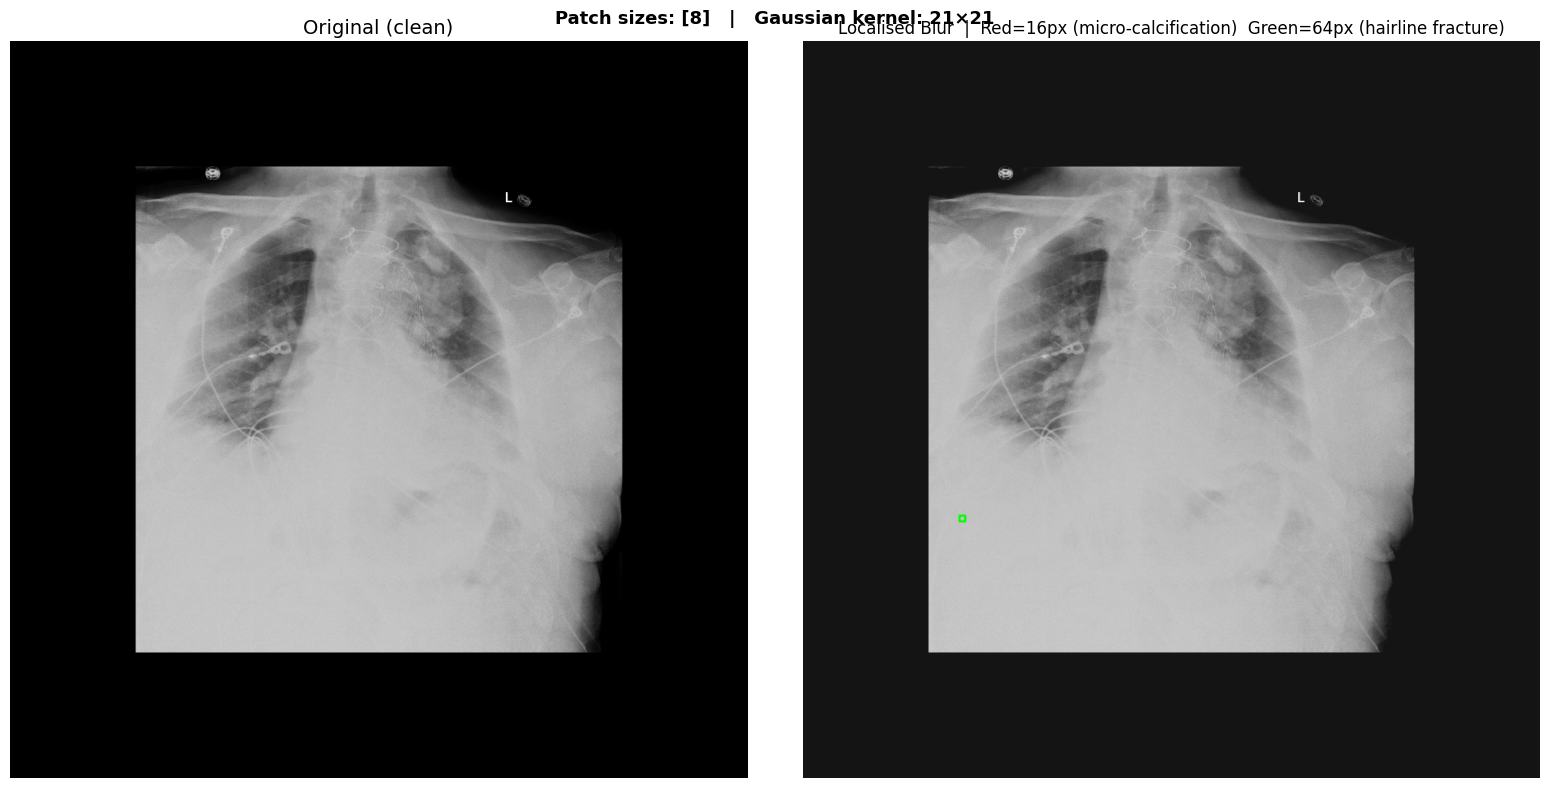

In [10]:
# ============================================================================
# OPTIONAL: VISUALISE PATCH INJECTION (sanity check before full run)
# ============================================================================
# Run this cell to confirm what the localised blur looks like on one image
# before committing to the full ~15 hr processing run.

def visualise_localized_blur(image_path, preprocessor, injector, save_path=None):
    """
    Side-by-side comparison: original vs localised-blur image.
    Draws red rectangles over patch locations for inspection.
    """
    processed, _  = preprocessor.pad_to_square_and_resize(image_path)
    noisy, meta   = injector.add_localized_blur(
        processed, patch_sizes=PATCH_SIZES, num_patches=NUM_PATCHES,
        blur_ksize=BLUR_KSIZE, blur_sigma=BLUR_SIGMA, image_path=image_path
    )

    # Draw patch bounding boxes on the noisy version (for visualisation only)
    noisy_annotated = noisy.copy()
    for p in meta['patch_locations']:
        y, x, ps = p['y'], p['x'], p['size']
        colour = (0, 0, 255) if ps == 16 else (0, 255, 0)  # red=16px, green=64px
        cv2.rectangle(noisy_annotated, (x, y), (x+ps, y+ps), colour, 2)

    # Convert BGR → RGB for matplotlib
    orig_rgb  = cv2.cvtColor(processed,      cv2.COLOR_BGR2RGB)
    noisy_rgb = cv2.cvtColor(noisy_annotated, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(orig_rgb,  cmap='gray')
    axes[0].set_title('Original (clean)', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(noisy_rgb, cmap='gray')
    axes[1].set_title(
        f'Localised Blur  |  Red=16px (micro-calcification)  Green=64px (hairline fracture)',
        fontsize=12
    )
    axes[1].axis('off')

    plt.suptitle(
        f'Patch sizes: {meta["patch_sizes_used"]}   |   '
        f'Gaussian kernel: {BLUR_KSIZE}×{BLUR_KSIZE}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved visualisation: {save_path}")
    plt.show()


# --- Uncomment and run with one sample image before the full pipeline ---
sample_img = "/home/rmuthy2/central_data/datasets/internal/EmoryCXRv2/ORIGINAL_PNG/29724709/7249714724266477/1.2.826.0.1.3680043.8.498.59672014537882090392569897035501547582.png"
prep  = ImagePreprocessor()
inj   = LocalizedBlurInjector(seed=42)
visualise_localized_blur(sample_img, prep, inj,
    save_path=os.path.join(OUTPUT_DIR, 'sample_patch_visualisation.png'))

Saved visualisation: /home/rmuthy2/Machine-Induced Noise/Localized_Blur_8*8/sample_patch_visualisation.png


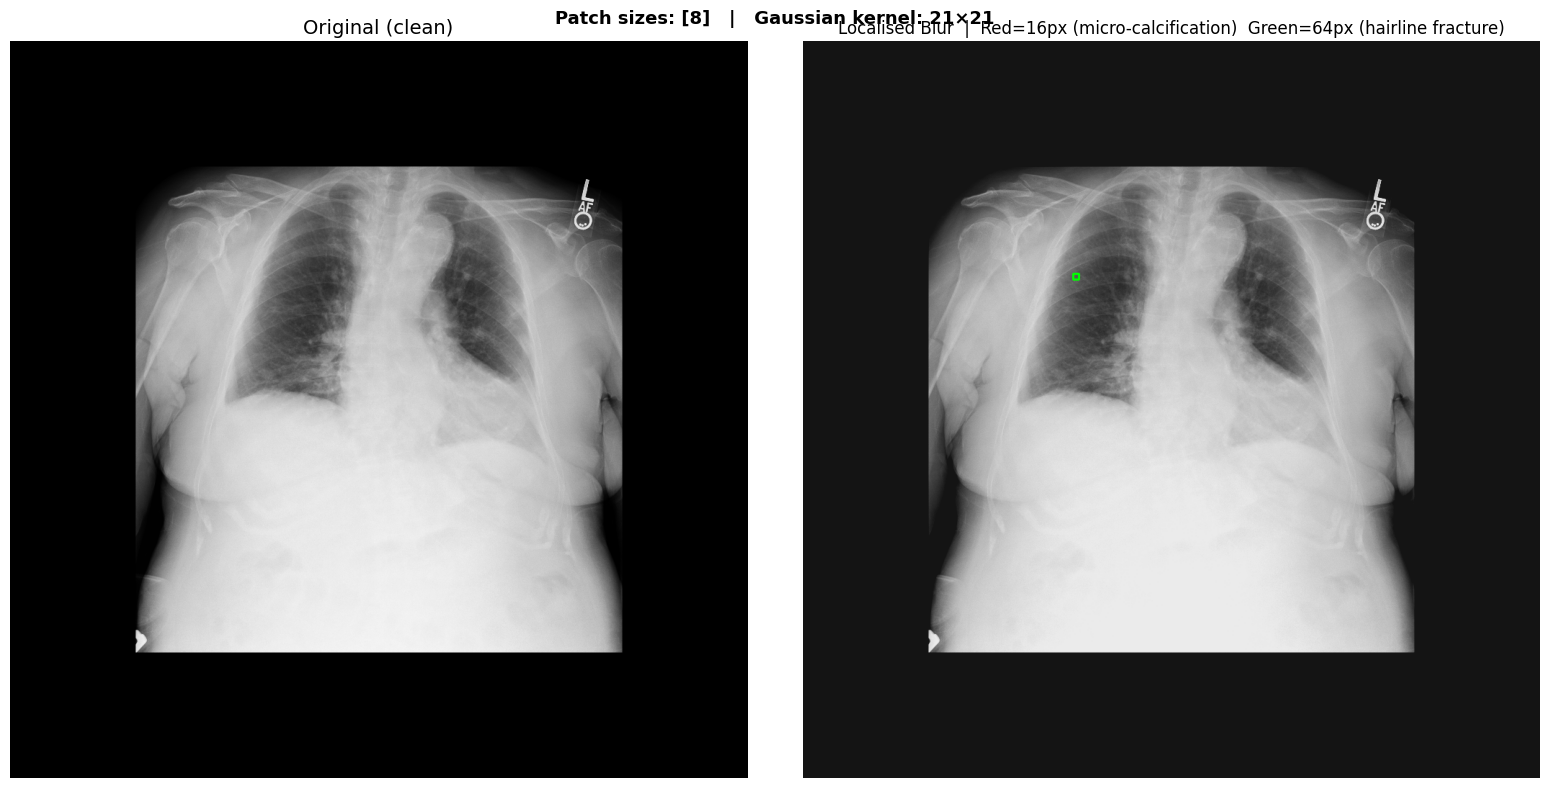

In [11]:
sample_img = "/home/rmuthy2/central_data/datasets/internal/EmoryCXRv2/ORIGINAL_PNG/11658596/454248444196/1.2.826.0.1.3680043.8.498.25813345165951161080075079897752249017.png"
prep  = ImagePreprocessor()
inj   = LocalizedBlurInjector(seed=42)
visualise_localized_blur(sample_img, prep, inj,
    save_path=os.path.join(OUTPUT_DIR, 'sample_patch_visualisation.png'))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



LOCALISED BLUR NOISE — COMPLETE PIPELINE WITH CONFIDENCE INTERVALS
Patch sizes : [8] px 
Num patches : 1 per image
Gaussian k  : 21×21  sigma=0
Placement   : central 60% of image (anatomical zone)
Batch size  : 12
Output      : /home/rmuthy2/Machine-Induced Noise/Localized_Blur_8*8
Using device: cuda
Loading RAD-DINO model...
RAD-DINO model loaded successfully
Loading DINOv3 model...


Loading checkpoint shards: 100%|██████████| 6/6 [00:00<00:00,  8.89it/s]


DINOv3 model loaded successfully

PROCESSING TRAIN SET


Processing train:   0%|          | 10/9152 [00:59<14:52:28,  5.86s/it]

...

Processing test: 100%|█████████▉| 2280/2288 [4:34:45<00:56,  7.12s/it]


Batch 2280/2288: Time=7.23s, Images/sec=1.66
Estimated remaining time: 1.0 minutes


Processing test: 100%|██████████| 2288/2288 [4:36:01<00:00,  7.24s/it]


Batch 2288/2288: Time=7.74s, Images/sec=1.55



Saved: /home/rmuthy2/Machine-Induced Noise/Localized_Blur_8*8/localized_blur_test.parquet
Total samples: 54912 ({0: 27456, 1: 27456})

LINEAR PROBING ANALYSIS WITH CONFIDENCE INTERVALS
Bootstrap samples: 1000, Confidence level: 95%

Loading embeddings...
Train samples: 219648, Test samples: 54912

Training RADDINO...
Computing 95% CI (1000 bootstrap samples)...
RADDINO - AUC: 0.7393 [0.7354, 0.7431] | F1@0.375: 0.7085 [0.7046, 0.7122]
              precision    recall  f1-score   support

           0     0.7473    0.4618    0.5708     27456
           1     0.6106    0.8438    0.7085     27456

    accuracy                         0.6528     54912
   macro avg     0.6789    0.6528    0.6397     54912
weighted avg     0.6789    0.6528    0.6397     54912


Training DINOV3...
Computing 95% CI (1000 bootstrap samples)...
DINOV3 - AUC: 1.0000 [0.9999, 1.0000] | F1@0.499: 0.9989 [0.9986, 0.9992]
              precision    recall  f1-score   support

           0     0.9992    0.9986    0.

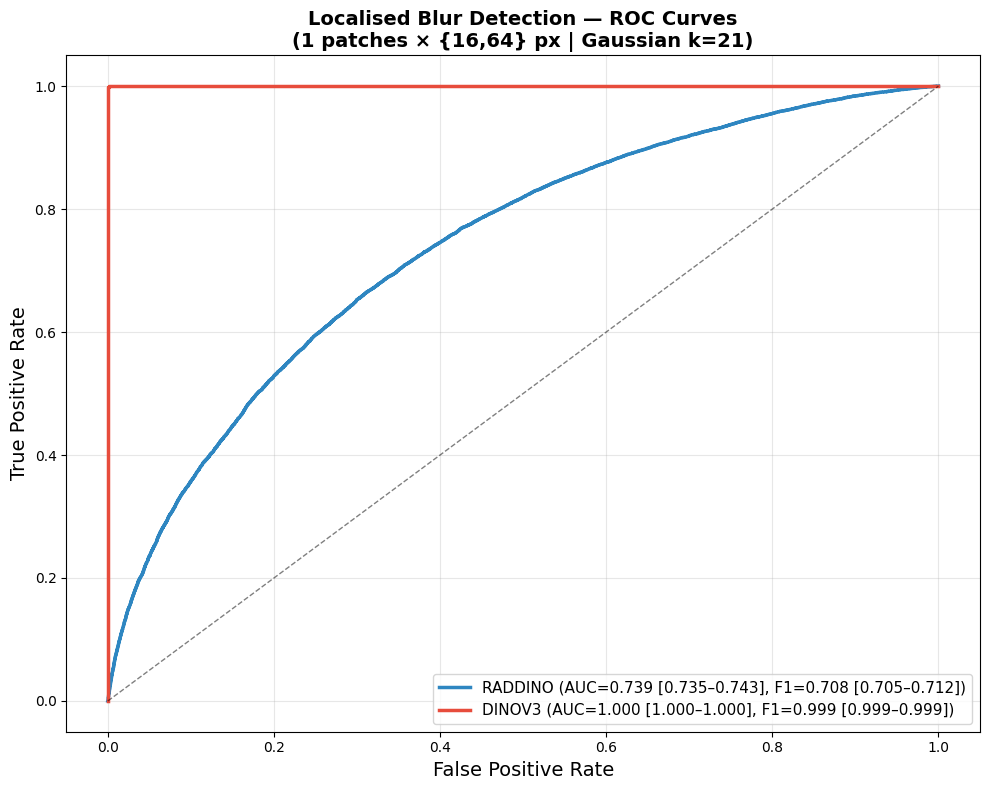

Plot saved: /home/rmuthy2/Machine-Induced Noise/Localized_Blur_8*8/localized_blur_roc_curves.png

RESULTS SUMMARY
Model      | AUC                              | F1                               | Threshold
--------------------------------------------------------------------------------
RADDINO    | 0.7393 [0.7354–0.7431]           | 0.7085  [0.7046–0.7122]          | 0.375
DINOV3     | 1.0000 [0.9999–1.0000]           | 0.9989  [0.9986–0.9992]          | 0.499

✅ COMPLETE! Results in: /home/rmuthy2/Machine-Induced Noise/Localized_Blur_8*8
Note: AUC ≈ 0.5 would confirm embeddings do not encode localised blur.


In [12]:
# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    print(f"\n{'='*70}")
    print("LOCALISED BLUR NOISE — COMPLETE PIPELINE WITH CONFIDENCE INTERVALS")
    print(f"{'='*70}")
    print(f"Patch sizes : {PATCH_SIZES} px ")
    print(f"Num patches : {NUM_PATCHES} per image")
    print(f"Gaussian k  : {BLUR_KSIZE}×{BLUR_KSIZE}  sigma={BLUR_SIGMA}")
    print(f"Placement   : central {int((1-2*PLACEMENT_MARGIN)*100)}% of image (anatomical zone)")
    print(f"Batch size  : {BATCH_SIZE}")
    print(f"Output      : {OUTPUT_DIR}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    tracker      = ProgressTracker(OUTPUT_DIR)
    preprocessor = ImagePreprocessor()
    injector     = LocalizedBlurInjector(seed=42)
    extractor    = EmbeddingExtractor()

    # ---- Train ----
    train_task = "train_processing"
    if not tracker.is_task_completed(train_task):
        tracker.set_current_task(train_task)
        train_path = process_dataset(
            TRAIN_CSV, "train", preprocessor, injector, extractor,
            batch_size=BATCH_SIZE, save_intermediate=True,
            intermediate_save_frequency=50
        )
        tracker.mark_task_completed(train_task)
    else:
        print("\nTrain dataset already processed. Skipping...")
        train_path = os.path.join(OUTPUT_DIR, "localized_blur_train.parquet")

    # ---- Test ----
    test_task = "test_processing"
    if not tracker.is_task_completed(test_task):
        tracker.set_current_task(test_task)
        test_path = process_dataset(
            TEST_CSV, "test", preprocessor, injector, extractor,
            batch_size=BATCH_SIZE, save_intermediate=True,
            intermediate_save_frequency=50
        )
        tracker.mark_task_completed(test_task)
    else:
        print("\nTest dataset already processed. Skipping...")
        test_path = os.path.join(OUTPUT_DIR, "localized_blur_test.parquet")

    # ---- Linear Probing ----
    lp_task = "linear_probing"
    if not tracker.is_task_completed(lp_task):
        tracker.set_current_task(lp_task)
        analyzer = run_linear_probing(
            train_path, test_path,
            n_bootstrap=1000,
            confidence_level=0.95
        )
        tracker.mark_task_completed(lp_task)
    else:
        print("\nLinear probing already completed. Skipping...")

    print(f"\n✅ COMPLETE! Results in: {OUTPUT_DIR}")
    print("Note: AUC ≈ 0.5 would confirm embeddings do not encode localised blur.")